# Senator Filings Analysis

***

## Imports

In [1]:
from collections import defaultdict
import datetime as dt
from functools import lru_cache
import os
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests


In [2]:
import pandas as pd

df = pd.read_parquet("transactions.parquet", engine="fastparquet")


In [5]:
insert_sql = """
INSERT INTO transactions
(full_name, ticker, side, tx_date, tx_estimate, asset_name, file_date)
VALUES (%s, %s, %s, %s, %s, %s, %s);
"""
row = df.iloc[0]
cur = conn.cursor()
cur.execute("SELECT 1;")
print(cur.fetchone())

cur.execute(
    insert_sql,
    (
        row["full_name"],
        row["ticker"],
        row["side"],
        row["tx_date"].date(),
        int(row["tx_estimate"]) if pd.notna(row["tx_estimate"]) else None,
        row.get("asset_name"),
        row["file_date"].date() if pd.notna(row["file_date"]) else None,
    )
)

conn.commit()


(1,)


In [7]:
for _, row in df.iterrows():
    cur.execute(
        insert_sql,
        (
            row["full_name"],
            row["ticker"],
            row["side"],
            row["tx_date"].date(),
            int(row["tx_estimate"]) if pd.notna(row["tx_estimate"]) else None,
            row.get("asset_name"),
            row["file_date"].date() if pd.notna(row["file_date"]) else None,
        )
    )

conn.commit()


In [8]:
cur.execute("""
    SELECT ticker, COUNT(DISTINCT full_name) AS n_senators
    FROM transactions
    WHERE side = 'BUY'
    GROUP BY ticker
    ORDER BY n_senators DESC;
""")

rows = cur.fetchall()
rows[:10]


[('AAPL', 20),
 ('MSFT', 17),
 ('AMZN', 14),
 ('XOM', 13),
 ('JPM', 13),
 ('NVDA', 12),
 ('DIS', 12),
 ('CSCO', 11),
 ('PG', 11),
 ('T', 11)]

In [9]:
cur.close()
conn.close()

## Introduction

In this notebook, we explore stock orders that were publicly filed by U.S. senators. The filings are scraped from https://efdsearch.senate.gov/search/. We calculate the returns of each senator by mimicking their buys and sells.

***

## Loading data

The `senators.pickle` file is scraped using the script in the root of the repository.

In [5]:
with open('senators2.pickle', 'rb') as f:
    raw_senators_tx = pickle.load(f)

In [6]:
with open('senators_clean.pickle', 'rb') as f:
    raw_senators_tx2 = pickle.load(f)

## Data cleaning

### Filling in missing tickers

In this section, we fill in as many of the missing ticker symbols as we can.

In [3]:
import json  # <-- REQUIRED for blacklist.json

def tokenize(asset_name):
    """ Convert an asset name into useful tokens. """
    token_string = (
        asset_name
        .replace('(', '')
        .replace(')', '')
        .replace('-', ' ')
        .replace('.', '')
    )
    return token_string.split(' ')

def token_is_ticker(token, token_blacklist):
    return len(token) <= 4 and token.upper() not in token_blacklist

# These generic words do not help us determine the ticker
with open('blacklist.json', 'r') as f:
    blacklist = set(json.load(f))

missing_tickers = set(
    raw_senators_tx[
        (raw_senators_tx['ticker'] == '--') |
        (raw_senators_tx['ticker'] == '')
    ]['asset_name']
)

ticker_map = {}
unmapped_tickers = set()

for m in missing_tickers:
    tokens = tokenize(m)
    if tokens and token_is_ticker(tokens[0], blacklist):
        ticker_map[m] = tokens[0].upper()
    elif tokens and token_is_ticker(tokens[-1], blacklist):
        ticker_map[m] = tokens[-1].upper()
    else:
        unmapped_tickers.add(m)


As a second pass, we assign tickers to asset names that have any of the specified keywords.

In [4]:
phrase_to_ticker = {
    'FOX': 'FOX',
    'AMAZON': 'AMZN',
    'AARON': 'AAN',
    'ALTRIA': 'MO',
    'APPLE': 'AAPL',
    'CHEVRON': 'CVX',
    'DUPONT': 'DD',
    'ALPHABET': 'GOOGL',
    'GOOG': 'GOOGL',
    'GENERAL ELECTRIC': 'GE',
    'JOHNSON': 'JNJ',
    'NEWELL': 'NWL',
    'OWENS': 'OMI',
    'PFIZER': 'PFE',
    'TYSON': 'TSN',
    'UNDER ARMOUR': 'UAA',
    'VERIZON': 'VZ',
    'WALT': 'DIS'
}

for m in unmapped_tickers:
    m_up = m.upper()
    for phrase, ticker in phrase_to_ticker.items():
        if phrase in m_up:
            ticker_map[m] = ticker.strip().upper()
            break

tx_with_tickers = raw_senators_tx.copy()

# Apply mapped tickers (cleaned)
for asset_name, ticker in ticker_map.items():
    tx_with_tickers.loc[
        tx_with_tickers['asset_name'] == asset_name,
        'ticker'
    ] = ticker

# Final ticker cleanup (IMPORTANT)
tx_with_tickers['ticker'] = (
    tx_with_tickers['ticker']
    .astype(str)
    .str.strip()
    .str.upper()
)


### Filtering rows and columns

We filter out useless rows and missing symbols, and then add some useful columns for the final dataset.

In [5]:
filtered_tx = tx_with_tickers.copy()

# Clean ticker column properly
filtered_tx["ticker"] = (
    filtered_tx["ticker"]
    .astype(str)
    .str.replace("--", "", regex=False)
    .str.replace("\n", "", regex=False)
    .str.strip()
    .str.upper()
)

# Drop rows with empty tickers
filtered_tx = filtered_tx[filtered_tx["ticker"] != ""]

# Drop exchanges (no market transaction)
filtered_tx = filtered_tx[filtered_tx["order_type"] != "Exchange"]


In [6]:
def parse_tx_amount(amt):
    """Get the lower bound for the transaction amount."""
    s = str(amt).strip()
    if not s or s == "nan":
        return np.nan

    # Normalize special "Over ..." cases (keep the lower bound)
    s = s.replace("Over $50,000,000", "$50,000,000 - $50,000,000")

    # Take the lower bound
    low = s.split(" - ")[0]
    low = low.replace(",", "").replace("$", "")

    try:
        return int(low)
    except ValueError:
        return np.nan

senators_tx = filtered_tx.assign(
    tx_estimate=filtered_tx["tx_amount"].map(parse_tx_amount)
)

senators_tx = senators_tx.assign(
    full_name=(
        senators_tx["first_name"].astype(str).str.strip()
        + " "
        + senators_tx["last_name"].astype(str).str.strip()
    )
)

useful_cols = [
    "file_date",
    "tx_date",
    "full_name",
    "order_type",
    "ticker",
    "tx_estimate",
]
senators_tx = senators_tx[useful_cols]

# Robust date parsing (works whether already datetime or string)
senators_tx["tx_date"] = pd.to_datetime(senators_tx["tx_date"], errors="coerce")
senators_tx["file_date"] = pd.to_datetime(senators_tx["file_date"], errors="coerce")

# Drop rows where required fields are missing
senators_tx = senators_tx.dropna(subset=["tx_date", "file_date", "ticker", "tx_estimate"])

senators_tx


,file_date,tx_date,full_name,order_type,ticker,tx_estimate
0,2026-01-30,2026-01-27,Tina Smith,Sale (Partial),BRK.B,100001
1,2026-01-30,2026-01-27,Tina Smith,Sale (Full),MRSH,50001
2,2026-01-29,2026-01-28,Katie Britt,Sale (Full),JPM,1001
3,2026-01-26,2025-04-14,Katie Britt,Purchase,XOM,1001
4,2026-01-26,2025-04-14,Katie Britt,Purchase,JPM,1001
...,...,...,...,...,...,...
12876,2014-01-31,2014-01-29,Susan M Collins,Sale (Partial),C,1001
12877,2014-01-31,2014-01-28,Susan M Collins,Sale (Partial),EBAY,1001
12878,2014-01-31,2014-01-24,Susan M Collins,Purchase,FB,1001
12879,2014-01-31,2014-01-24,Susan M Collins,Purchase,CRM,1001


In [18]:
raw_senators_tx

,tx_date,file_date,last_name,first_name,order_type,ticker,asset_name,tx_amount
0,01/27/2026,01/30/2026,Smith,Tina,Sale (Partial),BRK.B,Berkshire Hathaway Cl B,"$100,001 - $250,000"
1,01/27/2026,01/30/2026,Smith,Tina,Sale (Full),--,"MRSH - Marsh & McLennan Companies, Inc. Common...","$50,001 - $100,000"
2,01/28/2026,01/29/2026,Britt,Katie,Sale (Full),JPM,JP Morgan Chase & Company,"$1,001 - $15,000"
3,04/14/2025,01/26/2026,Britt,Katie,Purchase,XOM,Exxon Mobil Corp,"$1,001 - $15,000"
4,04/14/2025,01/26/2026,Britt,Katie,Purchase,JPM,JP Morgan Chase & Company,"$1,001 - $15,000"
...,...,...,...,...,...,...,...,...
12876,01/29/2014,01/31/2014,Collins,Susan M,Sale (Partial),C,"Citigroup, Inc. (NYSE)","$1,001 - $15,000"
12877,01/28/2014,01/31/2014,Collins,Susan M,Sale (Partial),EBAY,eBay Inc. (NASDAQ),"$1,001 - $15,000"
12878,01/24/2014,01/31/2014,Collins,Susan M,Purchase,FB,"Facebook, Inc. (NASDAQ)","$1,001 - $15,000"
12879,01/24/2014,01/31/2014,Collins,Susan M,Purchase,CRM,"Salesforce.com, Inc (NYSE)","$1,001 - $15,000"


In [19]:
senators_tx

,file_date,tx_date,full_name,order_type,ticker,tx_estimate
0,2026-01-30,2026-01-27,Tina Smith,Sale (Partial),BRK.B,100001
1,2026-01-30,2026-01-27,Tina Smith,Sale (Full),MRSH,50001
2,2026-01-29,2026-01-28,Katie Britt,Sale (Full),JPM,1001
3,2026-01-26,2025-04-14,Katie Britt,Purchase,XOM,1001
4,2026-01-26,2025-04-14,Katie Britt,Purchase,JPM,1001
...,...,...,...,...,...,...
12876,2014-01-31,2014-01-29,Susan M Collins,Sale (Partial),C,1001
12877,2014-01-31,2014-01-28,Susan M Collins,Sale (Partial),EBAY,1001
12878,2014-01-31,2014-01-24,Susan M Collins,Purchase,FB,1001
12879,2014-01-31,2014-01-24,Susan M Collins,Purchase,CRM,1001


In [20]:
df = senators_tx.copy()
df["side"] = df["order_type"].str.contains("Purchase", case=False)\
                .map({True: "BUY", False: "SELL"})

In [21]:
df["tx_date"] = pd.to_datetime(df["tx_date"])
df["week"] = df["tx_date"].dt.to_period("W-MON")

In [30]:
df.head()

,file_date,tx_date,full_name,order_type,ticker,tx_estimate,side,week,asset_name,tx_amount
0,2026-01-30,2026-01-27,Tina Smith,Sale (Partial),BRK.B,100001,SELL,2026-01-27/2026-02-02,Berkshire Hathaway Cl B,"$100,001 - $250,000"
1,2026-01-30,2026-01-27,Tina Smith,Sale (Full),MRSH,50001,SELL,2026-01-27/2026-02-02,NaN,NaN
2,2026-01-29,2026-01-28,Katie Britt,Sale (Full),JPM,1001,SELL,2026-01-27/2026-02-02,JP Morgan Chase & Company,"$1,001 - $15,000"
3,2026-01-26,2025-04-14,Katie Britt,Purchase,XOM,1001,BUY,2025-04-08/2025-04-14,Exxon Mobil Corp,"$1,001 - $15,000"
4,2026-01-26,2025-04-14,Katie Britt,Purchase,JPM,1001,BUY,2025-04-08/2025-04-14,JP Morgan Chase & Company,"$1,001 - $15,000"


In [26]:
dfA = raw_senators_tx.copy()
dfA["full_name"] = dfA["first_name"] + " " + dfA["last_name"]
dfA["tx_date"] = pd.to_datetime(dfA["tx_date"])

df = df.merge(
    dfA[["full_name", "tx_date", "ticker", "asset_name", "tx_amount"]],
    left_on=["full_name", "tx_date", "ticker"],
    right_on=["full_name", "tx_date", "ticker"],
    how="left"
)

In [37]:
df["tx_date"] = pd.to_datetime(df["tx_date"])

w = df["tx_date"].dt.to_period("W-MON")   # this is Period
df["week_start"] = w.dt.start_time        # datetime64[ns]
df["week_end"]   = w.dt.end_time          # datetime64[ns]
df["week_label"] = df["week_start"].dt.strftime("%Y-%m-%d")  # optional UI label

df.to_parquet("transactions.parquet", engine="fastparquet", index=False)

In [40]:
weekly = (
    df.groupby(["week", "ticker", "side"])
      .agg(
          n_senators=("full_name", "nunique"),
          n_trades=("full_name", "count"),
          total_estimate=("tx_estimate", "sum")
      )
      .reset_index()
)


In [47]:
df["tx_date"] = pd.to_datetime(df["tx_date"])
df["month"] = df["tx_date"].dt.to_period("M")   # e.g. 2026-01


In [49]:
monthly = (
    df.groupby(["month", "ticker", "side"])
      .agg(
          n_senators=("full_name", "nunique"),
          n_trades=("full_name", "count"),
          total_estimate=("tx_estimate", "sum")
      )
      .reset_index()
)


In [50]:
monthly["month_start"] = monthly["month"].dt.to_timestamp()
monthly["month_label"] = monthly["month"].astype(str)
monthly = monthly.drop(columns=["month"])


In [54]:
monthly[monthly["n_senators"] > 2]

,ticker,side,n_senators,n_trades,total_estimate,month_start,month_label
757,PG,BUY,3,19,159019,2015-04-01,2015-04
879,AAPL,BUY,3,4,32004,2015-08-01,2015-08
1140,AAPL,BUY,3,70,343070,2016-01-01,2016-01
1457,BMY,BUY,3,3,66003,2016-08-01,2016-08
1989,AAPL,SELL,3,6,146006,2017-06-01,2017-06
2151,AAPL,SELL,4,4,4004,2017-08-01,2017-08
2421,XOM,BUY,3,4,53004,2017-11-01,2017-11
2710,IBM,BUY,3,3,52003,2018-04-01,2018-04
2739,PG,BUY,3,6,20006,2018-04-01,2018-04
3010,GE,SELL,3,4,18004,2018-10-01,2018-10


In [55]:
weekly.to_parquet("weekly_activity.parquet", engine="fastparquet", index=False)
monthly.to_parquet("monthly_activity.parquet", engine="fastparquet", index=False)


## Returns calculation

These cells help us download the market data for the specified tickers. We store the market data in files so we don't need to repeatedly download the same information.

In [7]:
def _stooq_symbol(ticker: str) -> str:
    """
    Convert a US ticker like 'AAPL' into Stooq symbol 'AAPL.US'.
    If your dataset includes non-US tickers, you'll need a mapping.
    """
    t = str(ticker).strip().upper()
    return f"{t}.US"


def download_for_ticker(ticker, check_cache=True):
    """
    Download daily prices for this ticker from Stooq and cache to disk.
    Saves a pickle with {'price': <DataFrame>} where DataFrame has columns:
    ['Date','Open','High','Low','Close','Volume'] (Stooq standard).
    """
    ticker = str(ticker).strip().upper()
    if not ticker:
        return  # skip empty / whitespace tickers

    path = f"stocks/{ticker}.pickle"
    if check_cache and os.path.exists(path):
        return

    sym = _stooq_symbol(ticker)
    url = f"https://stooq.com/q/d/l/?s={sym}&i=d"

    # Stooq returns CSV; sometimes an invalid symbol returns empty/short CSV
    try:
        df = pd.read_csv(url)
    except Exception as e:
        raise RuntimeError(f"{ticker}: failed to download from Stooq ({e})")

    if df is None or df.empty or "Date" not in df.columns or "Close" not in df.columns:
        raise RuntimeError(f"{ticker}: no price data from Stooq")

    # Parse dates and sort ascending
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df = df.dropna(subset=["Date", "Close"]).sort_values("Date")

    if df.empty:
        raise RuntimeError(f"{ticker}: no valid rows after parsing Stooq data")

    with open(path, "wb") as f:
        pickle.dump({"price": df.reset_index(drop=True)}, f)


def load_for_ticker(ticker):
    """Load the cached file of stock prices for this ticker."""
    ticker = str(ticker).strip().upper()
    with open(f"stocks/{ticker}.pickle", "rb") as f:
        dump = pickle.load(f)

    raw = dump["price"].copy()
    # Standardize output columns used downstream
    out = raw[["Date", "Close"]].rename(columns={"Date": "date", "Close": "price"})
    out["date"] = pd.to_datetime(out["date"], errors="coerce")
    out = out.dropna(subset=["date", "price"]).sort_values("date")
    return out


def _price_for_date(df, date):
    """Helper for ticker_at_date: first available close on/after `date`."""
    date = pd.to_datetime(date)
    df2 = df[df["date"] >= date].sort_values(by="date")
    return float(df2["price"].iloc[0])  # raises IndexError if none


@lru_cache(maxsize=256)
def ticker_at_date(ticker, date):
    """
    Price of a ticker at a given date.
    Raises IndexError if there is no price on/after that date.
    """
    ticker = str(ticker).strip().upper()
    if not ticker:
        raise IndexError("Empty ticker")

    try:
        data = load_for_ticker(ticker)
        return _price_for_date(data, date)
    except Exception:
        # refresh cache then retry
        download_for_ticker(ticker, check_cache=False)
        data = load_for_ticker(ticker)
        return _price_for_date(data, date)


In [8]:
# Ensure cache directory exists
os.makedirs("stocks", exist_ok=True)

# Use a sorted list for reproducibility
all_tickers = sorted(set(senators_tx["ticker"].astype(str).str.strip().str.upper()))

import time

for i, t in enumerate(all_tickers):
    if i % 50 == 0:
        print(f"Working on ticker {i}/{len(all_tickers)}")

    try:
        download_for_ticker(t)
        time.sleep(0.1)   # gentle throttle; Stooq is tolerant but be polite
    except Exception as e:
        print(f"Ticker {t} failed with exception: {e}")


Working on ticker 0/1436
Ticker 3M failed with exception: 3M: failed to download from Stooq (<urlopen error [WinError 10060] Impossibile stabilire la connessione. Risposta non corretta della parte connessa dopo l'intervallo di tempo oppure mancata risposta dall'host collegato>)
Ticker ADCT failed with exception: ADCT: failed to download from Stooq (<urlopen error [WinError 10060] Impossibile stabilire la connessione. Risposta non corretta della parte connessa dopo l'intervallo di tempo oppure mancata risposta dall'host collegato>)
Ticker AG failed with exception: AG: failed to download from Stooq (<urlopen error [WinError 10060] Impossibile stabilire la connessione. Risposta non corretta della parte connessa dopo l'intervallo di tempo oppure mancata risposta dall'host collegato>)
Working on ticker 50/1436
Ticker AMCP failed with exception: AMCP: failed to download from Stooq (<urlopen error [WinError 10060] Impossibile stabilire la connessione. Risposta non corretta della parte conness

### Mimicking buy + sell orders

We calculate a given senator's return by calculating the return between each buy or sell order, and then solving for the cumulative return. We convert that to a CAGR given the time period the senator was investing.

We keep track of how many units of each stock a senator is holding. If we ever see a filing that indicates the senator sold more than we estimated they are holding, we just sell all of the units we have on record. (We do not allow the senator to go short.)

In [9]:
buckets = [
    (1000, 15000),
    (15000, 50000),
    (50000, 100000),
    (100000, 250000),
    (250000, 500000),
    (500000, 1000000),
    (1000000, 5000000),
    (5000000, 25000000),
    (25000000, 50000000),
    (50000000, float("inf")),
]

def same_bucket(dollar_value_a, dollar_value_b):
    """
    If the dollar value of the stock units is roughly the same, sell all
    units.
    """
    for v1, v2 in buckets:
        if dollar_value_a >= v1 and dollar_value_a < v2:
            return dollar_value_b >= v1 and dollar_value_b < v2
    return False


def portfolio_value(stocks, date):
    """
    Value of a portfolio if each ticker has the specified number of units.
    Missing prices are ignored.
    """
    v = 0.0
    for s, units in stocks.items():
        if units == 0:
            continue
        try:
            v += ticker_at_date(str(s).strip().upper(), date) * units
        except Exception:
            # Swallow any missing/failed ticker pricing
            pass
    return v


def calculate_return(before_values, after_values, begin_date, end_date, tx_dates):
    """
    Calculate cumulative return and CAGR given the senators portfolio
    value over time.

    Safe version: does NOT pop from empty lists and handles short sequences.
    """
    # Need at least 2 transactions to do the original pop(0)/pop(-1) logic safely
    if before_values is None or after_values is None or tx_dates is None:
        return {"portfolio_return": 0.0, "annual_cagr": 0.0, "growth": None}

    if len(before_values) < 2 or len(after_values) < 2 or len(tx_dates) < 2:
        return {"portfolio_return": 0.0, "annual_cagr": 0.0, "growth": None}

    # Make copies so we don't mutate caller lists
    before_values = list(before_values)
    after_values  = list(after_values)
    tx_dates      = list(tx_dates)

    # Original logic: ignore first before-value and last after-value
    before_values.pop(0)
    after_values.pop(-1)

    growth = np.array(before_values, dtype=float) / np.array(after_values, dtype=float)

    # valid mask (avoid NaNs/inf)
    valid = np.isfinite(growth)
    if valid.sum() == 0:
        return {"portfolio_return": 0.0, "annual_cagr": 0.0, "growth": None}

    portfolio_return = float(np.prod(growth[valid]))

    years = (end_date - begin_date).days / 365
    if years <= 0:
        cagr = 0.0
    else:
        cagr = float(portfolio_return ** (1 / years))

    # Growth dataframe aligned with the same slices/mask
    tx_dates.pop(0)                 # aligns with before_values pop(0)
    tx_dates = np.array(tx_dates)   # now length matches growth
    tx_dates = tx_dates[valid]

    cumulative_growth = np.cumprod(growth[valid])
    growth_df = pd.DataFrame({"date": tx_dates, "cumulative_growth": cumulative_growth})

    return {
        "portfolio_return": portfolio_return,
        "annual_cagr": cagr,
        "growth": growth_df,
    }


from collections import defaultdict

def return_for_senator(rows, date_col="tx_date", debug=False, debug_limit=8):
    """
    Simulate a senator's buy/sell orders and calculate return.
    Includes robust checks + optional debug prints.
    """
    dbg_count = 0
    def dbg(msg):
        nonlocal dbg_count
        if debug and dbg_count < debug_limit:
            print(msg)
            dbg_count += 1

    if rows is None or len(rows) == 0:
        if debug:
            print("NO ROWS for senator")
        return {"portfolio_return": 0.0, "annual_cagr": 0.0, "growth": None}

    if date_col not in rows.columns:
        raise KeyError(f"Missing date_col='{date_col}' in rows.columns")

    stocks = defaultdict(float)
    portfolio_value_before_tx = []
    portfolio_value_after_tx = []
    tx_dates = []

    rows = rows.sort_values(by=date_col)

    if debug and "ticker" in rows.columns:
        tickers_clean = rows["ticker"].astype(str).str.strip()
        dbg(f"rows={len(rows)} | unique_tickers={tickers_clean.nunique()} | empty_tickers={(tickers_clean=='').sum()}")

    for _, row in rows.iterrows():
        date = row[date_col]
        if date_col == "file_date":
            date = date + dt.timedelta(days=1)

        ticker = str(row.get("ticker", "")).strip().upper()
        if not ticker:
            dbg("SKIP row: empty/blank ticker")
            continue

        try:
            sp = float(ticker_at_date(ticker, date))
        except Exception as e:
            dbg(f"SKIP row: price lookup failed for {ticker} on {date} ({type(e).__name__}: {e})")
            continue

        if not np.isfinite(sp) or sp <= 0:
            dbg(f"SKIP row: bad price for {ticker} on {date}: {sp}")
            continue

        try:
            value_before_tx = portfolio_value(stocks, date)
        except Exception as e:
            dbg(f"SKIP row: portfolio_value BEFORE failed on {date} ({type(e).__name__}: {e})")
            continue

        order_type = str(row.get("order_type", ""))

        if "Purchase" in order_type:
            tx_amt = float(row.get("tx_estimate", 0) or 0)
            if tx_amt > 0:
                stocks[ticker] += tx_amt / sp
            else:
                dbg(f"SKIP purchase: non-positive tx_estimate={tx_amt} for {ticker} on {date}")

        elif "Sale" in order_type:
            held = float(stocks.get(ticker, 0.0))
            if held <= 0:
                dbg(f"SKIP sale: no holdings for {ticker} on {date}")
            else:
                cur_val = sp * held
                tx_est = float(row.get("tx_estimate", 0) or 0)

                if ("Full" in order_type) or same_bucket(tx_est, cur_val):
                    stocks[ticker] = 0.0
                else:
                    stocks[ticker] = max(0.0, held - (tx_est / sp))

        else:
            dbg(f"SKIP row: unknown order_type='{order_type}' for {ticker} on {date}")
            continue

        try:
            value_after_tx = portfolio_value(stocks, date)
        except Exception as e:
            dbg(f"SKIP row: portfolio_value AFTER failed on {date} ({type(e).__name__}: {e})")
            continue

        portfolio_value_before_tx.append(value_before_tx)
        portfolio_value_after_tx.append(value_after_tx)
        tx_dates.append(date)

    # Let calculate_return decide if there's enough data; it now handles short/empty safely
    return calculate_return(
        portfolio_value_before_tx,
        portfolio_value_after_tx,
        begin_date=min(rows[date_col]),
        end_date=max(rows[date_col]),
        tx_dates=tx_dates,
    )


In [10]:
senator_returns = []
senator_tx_growth = {}
senator_file_growth = {}

senator_names = sorted(
    set(senators_tx["full_name"].dropna().astype(str).str.strip())
)


The following cell took my laptop about three hours to run.

In [11]:
failed_senators = {}
print(f"{len(senator_names)} senators total")

for idx, n in enumerate(senator_names):
    print(f"Starting {n}")

    if n in senator_tx_growth:
        continue

    try:
        rows_n = senators_tx[senators_tx["full_name"] == n]

        # Debug only for first N senators (change 3 -> whatever)
        dbg = (idx < 3)

        tx_return = return_for_senator(rows_n, date_col="tx_date", debug=dbg, debug_limit=15)
        file_return = return_for_senator(rows_n, date_col="file_date", debug=dbg, debug_limit=15)

        # If both failed to produce growth, skip senator
        if tx_return.get("growth") is None and file_return.get("growth") is None:
            print(f"Skipping {n}: no valid priced transactions")
            continue

        senator_returns.append({
            "full_name": n,
            "tx_total_return": float(tx_return.get("portfolio_return", 0.0) or 0.0),
            "tx_cagr": float(tx_return.get("annual_cagr", 0.0) or 0.0),
            "file_total_return": float(file_return.get("portfolio_return", 0.0) or 0.0),
            "file_cagr": float(file_return.get("annual_cagr", 0.0) or 0.0),
        })

        # Store growth only if present
        if tx_return.get("growth") is not None:
            senator_tx_growth[n] = tx_return["growth"]
        if file_return.get("growth") is not None:
            senator_file_growth[n] = file_return["growth"]

    except Exception as e:
        print(f"Failed senator {n} with exception {e}")
        failed_senators[n] = e


63 senators total
Starting A. Mitchell McConnell, Jr.
rows=42 | unique_tickers=6 | empty_tickers=0
SKIP sale: no holdings for IR on 2016-06-09 00:00:00
SKIP sale: no holdings for IR on 2017-02-02 00:00:00
SKIP row: price lookup failed for AMCP on 2017-04-21 00:00:00 (RuntimeError: AMCP: failed to download from Stooq (<urlopen error [WinError 10060] Impossibile stabilire la connessione. Risposta non corretta della parte connessa dopo l'intervallo di tempo oppure mancata risposta dall'host collegato>))
SKIP sale: no holdings for IR on 2019-06-03 00:00:00
SKIP sale: no holdings for VMC on 2019-06-03 00:00:00
SKIP row: price lookup failed for LAZR on 2025-06-26 00:00:00 (RuntimeError: LAZR: failed to download from Stooq (<urlopen error [WinError 10060] Impossibile stabilire la connessione. Risposta non corretta della parte connessa dopo l'intervallo di tempo oppure mancata risposta dall'host collegato>))
SKIP row: price lookup failed for LAZR on 2025-12-24 00:00:00 (RuntimeError: LAZR: fai

C:\Users\eliap\AppData\Local\Temp\ipykernel_31640\3758773999.py:65: RuntimeWarning: invalid value encountered in divide
  growth = np.array(before_values, dtype=float) / np.array(after_values, dtype=float)


SKIP row: price lookup failed for AMCP on 2017-05-16 00:00:00 (RuntimeError: AMCP: failed to download from Stooq (<urlopen error [WinError 10060] Impossibile stabilire la connessione. Risposta non corretta della parte connessa dopo l'intervallo di tempo oppure mancata risposta dall'host collegato>))
SKIP sale: no holdings for VMC on 2019-06-15 00:00:00
SKIP sale: no holdings for IR on 2019-06-15 00:00:00
SKIP row: price lookup failed for LAZR on 2025-07-08 00:00:00 (RuntimeError: LAZR: failed to download from Stooq (<urlopen error [WinError 10060] Impossibile stabilire la connessione. Risposta non corretta della parte connessa dopo l'intervallo di tempo oppure mancata risposta dall'host collegato>))
SKIP row: price lookup failed for LAZR on 2026-01-14 00:00:00 (RuntimeError: LAZR: failed to download from Stooq (<urlopen error [WinError 10060] Impossibile stabilire la connessione. Risposta non corretta della parte connessa dopo l'intervallo di tempo oppure mancata risposta dall'host col

C:\Users\eliap\AppData\Local\Temp\ipykernel_31640\3758773999.py:65: RuntimeWarning: invalid value encountered in divide
  growth = np.array(before_values, dtype=float) / np.array(after_values, dtype=float)


SKIP row: price lookup failed for SIAL on 2015-11-18 00:00:00 (RuntimeError: SIAL: failed to download from Stooq (<urlopen error [WinError 10060] Impossibile stabilire la connessione. Risposta non corretta della parte connessa dopo l'intervallo di tempo oppure mancata risposta dall'host collegato>))
SKIP sale: no holdings for KMI on 2015-12-16 00:00:00
SKIP sale: no holdings for EMC on 2016-07-14 00:00:00
SKIP sale: no holdings for GE on 2016-10-19 00:00:00
SKIP sale: no holdings for TEVA on 2016-10-19 00:00:00
SKIP sale: no holdings for TGT on 2017-05-03 00:00:00
SKIP sale: no holdings for DIS on 2017-05-03 00:00:00
SKIP sale: no holdings for IBM on 2017-07-20 00:00:00
SKIP sale: no holdings for CSCO on 2017-10-19 00:00:00
rows=69 | unique_tickers=58 | empty_tickers=0
SKIP sale: no holdings for XRAY on 2014-05-14 00:00:00
SKIP sale: no holdings for SRE on 2014-05-14 00:00:00
SKIP sale: no holdings for RYAM on 2014-08-26 00:00:00
SKIP sale: no holdings for RYN on 2014-12-13 00:00:00
SK

...

Skipping Cory A Booker: no valid priced transactions
Starting Cynthia M Lummis
Starting Daniel S Sullivan


C:\Users\eliap\AppData\Local\Temp\ipykernel_31640\3758773999.py:65: RuntimeWarning: invalid value encountered in divide
  growth = np.array(before_values, dtype=float) / np.array(after_values, dtype=float)
C:\Users\eliap\AppData\Local\Temp\ipykernel_31640\3758773999.py:65: RuntimeWarning: invalid value encountered in divide
  growth = np.array(before_values, dtype=float) / np.array(after_values, dtype=float)


Starting David A Perdue , Jr


KeyboardInterrupt: 

KeyboardInterrupt: 

In [13]:
senator_returns

[{'full_name': 'A. Mitchell McConnell, Jr.',
  'tx_total_return': 1.9854637372046915,
  'tx_cagr': 1.0744753243934368,
  'file_total_return': 1.9282025071948237,
  'file_cagr': 1.0786608144455407},
 {'full_name': 'Angus S King, Jr.',
  'tx_total_return': 5.092557721373933,
  'tx_cagr': 1.149550828085215,
  'file_total_return': 4.9875661150343555,
  'file_cagr': 1.147022351710466},
 {'full_name': 'Ashley Moody',
  'tx_total_return': 0.7687698736244947,
  'tx_cagr': 0.2685231788337822,
  'file_total_return': 0.8961583007325636,
  'file_cagr': 0.610151062428426},
 {'full_name': 'Christopher A Coons',
  'tx_total_return': 0.8341035614336274,
  'tx_cagr': 0.8588102533689833,
  'file_total_return': 1.0,
  'file_cagr': 0.0},
 {'full_name': 'Cynthia M Lummis',
  'tx_total_return': 1.0,
  'tx_cagr': 1.0,
  'file_total_return': 1.0,
  'file_cagr': 0.0},
 {'full_name': 'Daniel S Sullivan',
  'tx_total_return': 1.74734832844255,
  'tx_cagr': 1.0640142899910972,
  'file_total_return': 2.39731003016

We look at the results to see the senators that outperformed the market.

In [14]:
def plot_senator_growth(growth):
    """Plot the senator's portfolio growth against SPY (proxy for S&P 500)."""
    if growth is None or len(growth) < 2:
        print("No growth data to plot.")
        return

    # Senator growth
    plt.plot_date(growth["date"], growth["cumulative_growth"], "-", label="Senator")

    # SPY data (Stooq cached via your download_for_ticker/load_for_ticker)
    download_for_ticker("SPY")
    spy = load_for_ticker("SPY")

    start = pd.to_datetime(growth["date"].min())
    end   = pd.to_datetime(growth["date"].max())

    spy = spy[(spy["date"] >= start) & (spy["date"] <= end)].sort_values("date")

    if len(spy) < 2:
        print("Not enough SPY data in this date range to compare.")
        plt.show()
        return

    spy_prices = spy["price"].astype(float).reset_index(drop=True)

    # Make SPY cumulative growth start at 1 (like a normalized index)
    spy_cum = spy_prices / spy_prices.iloc[0]
    plt.plot_date(spy["date"], spy_cum, "-", label="SPY")

    plt.legend()
    plt.show()

    print(f"Earliest date: {start}")
    print(f"Latest date: {end}")
    print(f"Market return (SPY): {spy_prices.iloc[-1] / spy_prices.iloc[0]}")
    sen = growth["cumulative_growth"].astype(float).reset_index(drop=True)
    print(f"Senator return: {sen.iloc[-1] / sen.iloc[0]}")


In [15]:
returns = pd.DataFrame(senator_returns)

# Ensure numeric columns (robust to skipped senators)
for c in ["tx_total_return", "tx_cagr", "file_total_return", "file_cagr"]:
    returns[c] = pd.to_numeric(returns[c], errors="coerce")

# Drop rows without valid tx results
returns = returns.dropna(subset=["tx_total_return", "tx_cagr"])

# Original filtering logic
returns = returns[
    (returns["tx_total_return"] > returns["tx_cagr"]) &
    (returns["tx_cagr"] > 0)
]

returns = returns.sort_values("tx_cagr", ascending=True)
returns


,full_name,tx_total_return,tx_cagr,file_total_return,file_cagr
2,Ashley Moody,0.768770,0.268523,0.896158,0.610151
5,Daniel S Sullivan,1.747348,1.064014,2.397310,1.123242
0,"A. Mitchell McConnell, Jr.",1.985464,1.074475,1.928203,1.078661
1,"Angus S King, Jr.",5.092558,1.149551,4.987566,1.147022


C:\Users\eliap\AppData\Local\Temp\ipykernel_31640\606144383.py:8: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  plt.plot_date(growth["date"], growth["cumulative_growth"], "-", label="Senator")
C:\Users\eliap\AppData\Local\Temp\ipykernel_31640\606144383.py:28: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  plt.plot_date(spy["date"], spy_cum, "-", label="SPY")


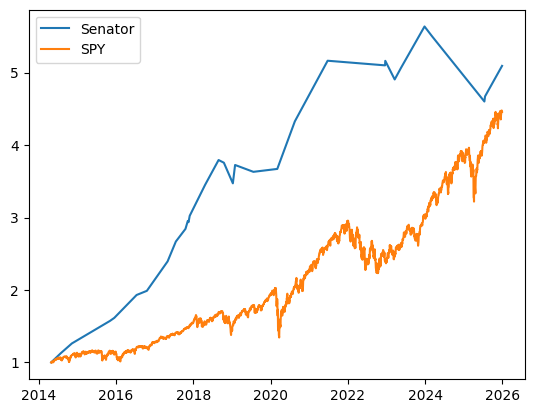

Earliest date: 2014-04-28 00:00:00
Latest date: 2025-12-29 00:00:00
Market return (SPY): 4.460475974320731
Senator return: 5.092557721373933


In [16]:
plot_senator_growth(senator_tx_growth['Angus S King, Jr.'])

## About this notebook

Author: Neel Somani, Software Engineer

Email: neel@berkeley.edu

Website: https://www.ocf.berkeley.edu/~neel/

Updated On: 2020-05-23